# Steam Workshop Benchmark

In this notebook we will compare popularities between different Steam game workshops using indicators from the front page mods. Front page mods are this weeks most popular mods based on their interaction numbers.


In [ ]:
!pip install matplotlib==3.10.6 \
numpy==2.3.3\
pandas==2.3.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path().resolve()
PATH_DIR = DATA_DIR / "Workshop Chart.csv"

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.2f}".format

ws = pd.read_csv(PATH_DIR)

ws.head()

,Game,Item,Ratings,Unique Visitors,Current Subs,Current Favs,Collections,Comments
0,GMOD,ttt,500,36393,12813,2225,1152,57
1,GMOD,litegibs,668,36602,7420,3699,853,131
2,GMOD,immersive,1066,33646,13995,3994,1681,256
3,GMOD,auto skirt,224,9570,3583,683,248,39
4,GMOD,beta citadel,334,14321,5944,1613,430,33


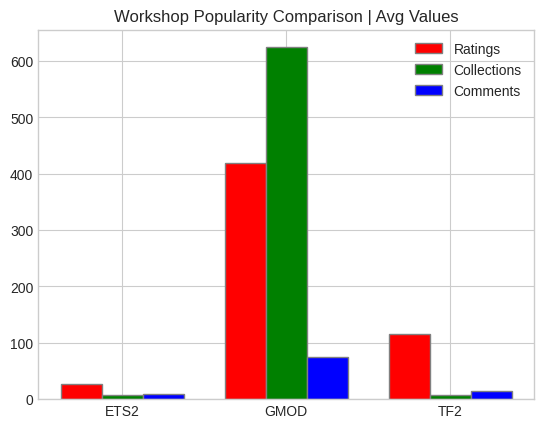

In [5]:
games = (
    ws["Game"]
    .sort_values()
    .unique()
)

avg_ratings = (
    ws.groupby('Game')['Ratings']
    .mean()
    .sort_index()
)

avg_visitors = (
    ws.groupby('Game')['Unique Visitors']
    .mean()
    .sort_index()
)

avg_subs = (
    ws.groupby('Game')['Current Subs']
    .mean()
    .sort_index()
)

avg_favs = (
    ws.groupby('Game')['Current Favs']
    .mean()
    .sort_index()
)

avg_collections = (
    ws.groupby('Game')['Collections']
    .mean()
    .sort_index()
)

avg_comments = (
    ws.groupby('Game')['Comments']
    .mean()
    .sort_index()
)

barWidth = 0.25
#fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(games))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

plt.bar(br1, avg_ratings, color ='r', width = barWidth, edgecolor ='grey', label ='Ratings')
plt.bar(br2, avg_collections, color ='g', width = barWidth, edgecolor ='grey', label ='Collections')
plt.bar(br3, avg_comments, color ='b', width = barWidth, edgecolor ='grey', label ='Comments')

plt.title('Workshop Popularity Comparison | Avg Values')

plt.xticks([r + barWidth for r in range(len(games))], games)

plt.legend()
plt.show()

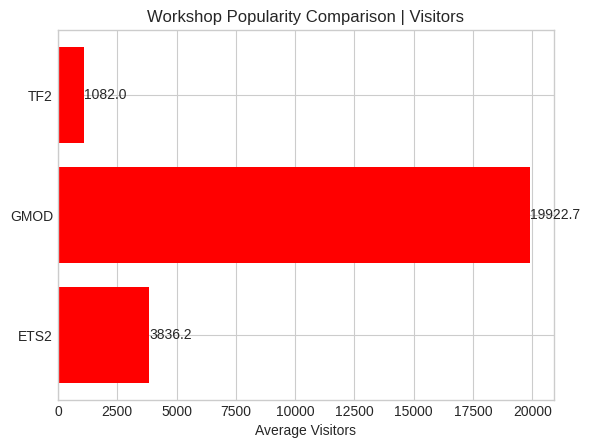

In [44]:
plt.barh(games, avg_visitors, color='r')

plt.title('Workshop Popularity Comparison | Visitors')
plt.xlabel('Average Visitors')

for idx, value in enumerate(avg_visitors.values):
    plt.text(value, idx, f'{value:.1f}', va='center', fontsize=10)

plt.show()

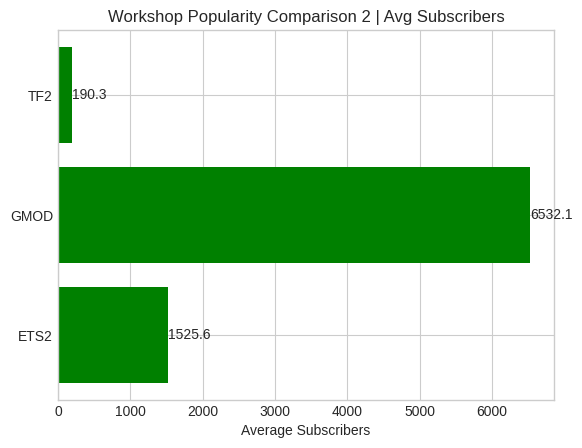

In [43]:
plt.barh(games, avg_subs, color='g')

plt.title('Workshop Popularity Comparison 2 | Avg Subscribers')
plt.xlabel('Average Subscribers')

for idx, value in enumerate(avg_subs.values):
    plt.text(value, idx, f'{value:.1f}', va='center', fontsize=10)

plt.show()

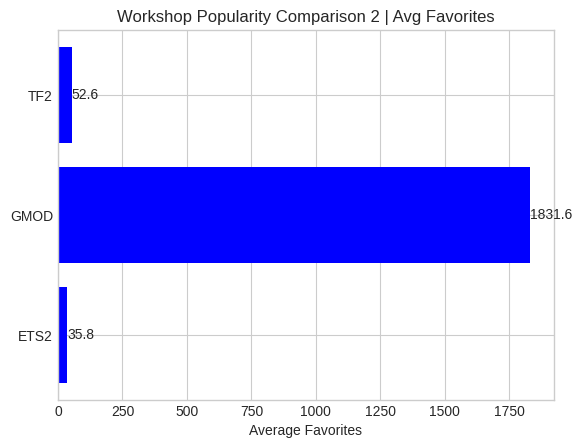

In [46]:
plt.barh(games, avg_favs, color='b')

plt.title('Workshop Popularity Comparison 2 | Avg Favorites')
plt.xlabel('Average Favorites')

for idx, value in enumerate(avg_favs.values):
    plt.text(value, idx, f'{value:.1f}', va='center', fontsize=10)

plt.show()

This notebook was meant to practice python stuff and convey that the GMOD Workshop is very active compared to other workshops.